In [ ]:
import pandas as pd

train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Columns:")
print(train_df.columns)

print("\nFirst 5 rows:")
print(train_df.head())

Train Shape: (1296675, 23)
Test Shape: (555719, 23)

Train Columns:
Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

First 5 rows:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainmen

In [2]:
print("Missing Values:")
print(train_df.isnull().sum())

print("\nDuplicate Rows:", train_df.duplicated().sum())

print("\nData Types:")
print(train_df.dtypes)

print("\nFraud Distribution:")
print(train_df['is_fraud'].value_counts())

print("\nFraud Percentage:")
print(train_df['is_fraud'].value_counts(normalize=True) * 100)

Missing Values:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Duplicate Rows: 0

Data Types:
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street               

In [3]:
drop_cols = [
    'Unnamed: 0',
    'trans_num',
    'first',
    'last',
    'street',
    'cc_num'
]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print(train_df.shape)
print(test_df.shape)

(1296675, 17)
(555719, 17)


In [ ]:
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])

for df in [train_df, test_df]:
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour
    df['trans_day'] = df['trans_date_trans_time'].dt.day
    df['trans_month'] = df['trans_date_trans_time'].dt.month

train_df['dob'] = pd.to_datetime(train_df['dob'])
test_df['dob'] = pd.to_datetime(test_df['dob'])

for df in [train_df, test_df]:
    df['age'] = 2026 - df['dob'].dt.year

train_df.drop(columns=['trans_date_trans_time', 'dob'], inplace=True)
test_df.drop(columns=['trans_date_trans_time', 'dob'], inplace=True)

print(train_df.head())

                             merchant       category     amt gender  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97      F   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23      F   
2                fraud_Lind-Buckridge  entertainment  220.11      M   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00      M   
4                 fraud_Keeling-Crist       misc_pos   41.96      M   

             city state    zip      lat      long  city_pop  \
0  Moravian Falls    NC  28654  36.0788  -81.1781      3495   
1          Orient    WA  99160  48.8878 -118.2105       149   
2      Malad City    ID  83252  42.1808 -112.2620      4154   
3         Boulder    MT  59632  46.2306 -112.1138      1939   
4        Doe Hill    VA  24433  38.4207  -79.4629        99   

                                 job   unix_time  merch_lat  merch_long  \
0          Psychologist, counselling  1325376018  36.011293  -82.048315   
1  Special educational needs teacher  132537

In [5]:
print(train_df.select_dtypes(include='object').columns.tolist())

['merchant', 'category', 'gender', 'city', 'state', 'job']


In [6]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    all_values = pd.concat([train_df[col], test_df[col]])

    le.fit(all_values)

    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

    encoders[col] = le

print(train_df.head())
print(train_df.dtypes)

   merchant  category     amt  gender  city  state    zip      lat      long  \
0       514         8    4.97       0   532     27  28654  36.0788  -81.1781   
1       241         4  107.23       0   619     47  99160  48.8878 -118.2105   
2       390         0  220.11       1   474     13  83252  42.1808 -112.2620   
3       360         2   45.00       1    84     26  59632  46.2306 -112.1138   
4       297         9   41.96       1   217     45  24433  38.4207  -79.4629   

   city_pop  job   unix_time  merch_lat  merch_long  is_fraud  trans_hour  \
0      3495  372  1325376018  36.011293  -82.048315         0           0   
1       149  431  1325376044  49.159047 -118.186462         0           0   
2      4154  308  1325376051  43.150704 -112.154481         0           0   
3      1939  330  1325376076  47.034331 -112.561071         0           0   
4        99  116  1325376186  38.674999  -78.632459         0           0   

   trans_day  trans_month  age  
0          1           

In [7]:
X_train = train_df.drop('is_fraud', axis=1)
y_train = train_df['is_fraud']

X_test = test_df.drop('is_fraud', axis=1)
y_test = test_df['is_fraud']

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1296675, 18)
(1296675,)
(555719, 18)
(555719,)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1296675, 18)
(555719, 18)


In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Training Completed")

Training Completed


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("Decision Tree Trained")
print("Random Forest Trained")

Decision Tree Trained
Random Forest Trained


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.970726   0.091325  0.735664  0.162479
1        Decision Tree  0.996820   0.562583  0.792075  0.657890
2        Random Forest  0.998609   0.953704  0.672261  0.788625


In [12]:
from sklearn.metrics import roc_auc_score

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

print("Logistic Regression AUC:", roc_auc_score(y_test, lr_probs))
print("Decision Tree AUC:", roc_auc_score(y_test, dt_probs))
print("Random Forest AUC:", roc_auc_score(y_test, rf_probs))

Logistic Regression AUC: 0.8496242922332298
Decision Tree AUC: 0.8948441402893743
Random Forest AUC: 0.97520624423333


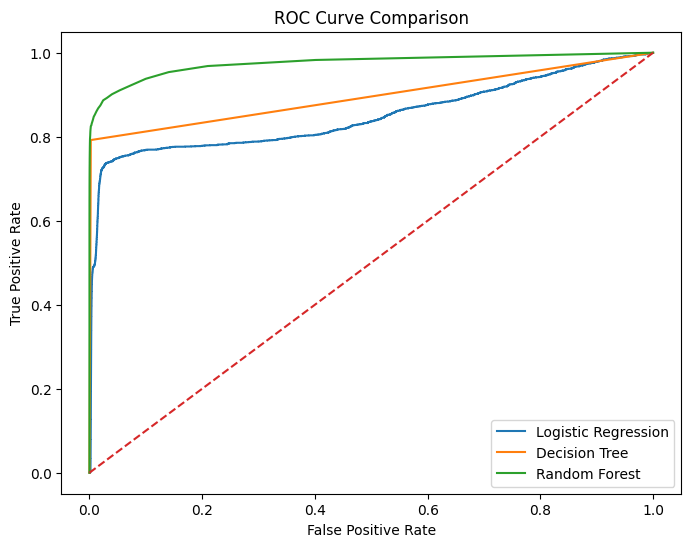

In [13]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

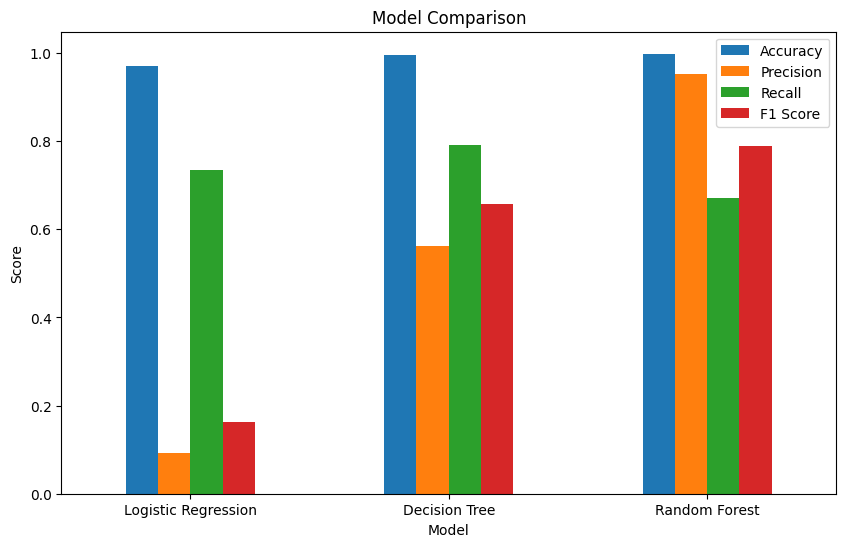

In [14]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [16]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

       Feature  Importance
2          amt    0.387498
1     category    0.158163
14  trans_hour    0.113820
17         age    0.054246
11   unix_time    0.033744
9     city_pop    0.029352
12   merch_lat    0.026772
13  merch_long    0.026652
0     merchant    0.022669
15   trans_day    0.021392


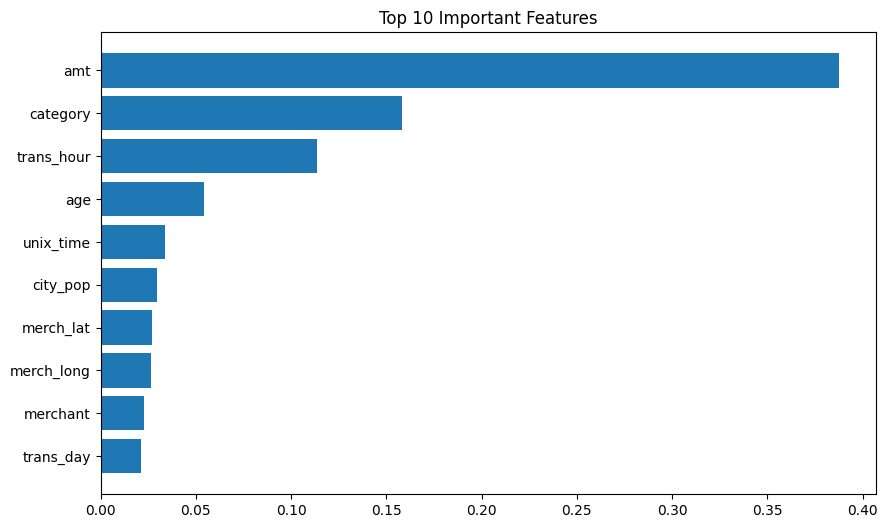

In [17]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

plt.show()

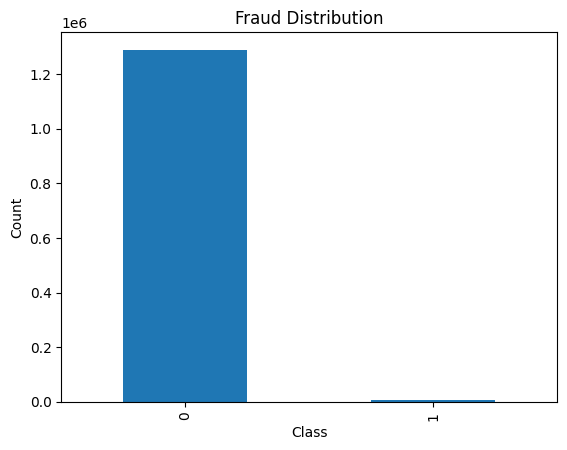

In [18]:
train_df['is_fraud'].value_counts().plot(
    kind='bar'
)

plt.title("Fraud Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()